# 202435119 한여원
# 타이타닉 classification
### 일단 인과관계가 없는 열도 한번 넣어보고, 인과관계가 있는 열만 넣은 결과와 비교해보자

In [42]:
# 202435119 한여원
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split

In [11]:
# logistic regression, decision tree, random forest를 해보도록 하자

In [43]:
# 데이터 만들기
# 레이블 인코딩, 결측치 확인 & 제거, 레이블 개수 확인, feature selection
# 데이터 전처리를 좀 해야하는데, 
# 1. 비어있는 값들(결측치)을 채워준다
# 2. 쓸모없는 열들을 삭제한다 (이름, id 등등등)
# 
# 2번 과정을 처리한 데이터, 처리하지 않은 데이터를 각각 만들어서 결과를 비교해볼 예정
# 

df1 = pd.read_csv(r"D:\hanyeowon\Coding\pythonworks\deep\AI-class-2026\week04\titanic.csv")


# 결측치 확인
print(df1.isnull().sum()) # 처리해야할 결측치는 총 3개, Age, Cabin, Embarked 이다
df1["Age"] = df1["Age"].fillna(df1["Age"].mean())
df1["Embarked"] = df1["Embarked"].fillna(df1["Embarked"].mode()[0])
df1 = df1.drop("Cabin", axis=1) # Cabin은 그냥 갖다 버리도록 하자. 결측치가 너무너무 많다
print(df1.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [44]:
# 또한 인코딩도 해줘야함.
# 이름, 성별, 티켓, Embarked 모두 str으로 되어있기에 인코딩이 필요하다
# 이름과 티켓은 그냥 길이를 확인하는 걸로 하고, 성별과 Embarked는 인코딩을 해주자
print(df1.dtypes)
df1["Sex"] = df1["Sex"].map({"male": 0, "female": 1})
df1["Name"] = df1["Name"].apply(len)
df1["Ticket"] = df1["Ticket"].apply(len)
df1 = pd.get_dummies(df1, columns=["Embarked"])
print(df1.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Embarked           str
dtype: object
PassengerId      int64
Survived         int64
Pclass           int64
Name             int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket           int64
Fare           float64
Embarked_C        bool
Embarked_Q        bool
Embarked_S        bool
dtype: object


In [45]:
print(df1.isnull().sum()) # 결측치 처리 완료
print(df1.dtypes)
# 쓸모 없는 열들: id, name, Ticket
df2 = df1.drop(["PassengerId", "Ticket", "Name"], axis=1)
# 이제 feature select가 끝난 df2가 완성되었다. 이를 df1와 비교해보면 된다.

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
dtype: int64
PassengerId      int64
Survived         int64
Pclass           int64
Name             int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket           int64
Fare           float64
Embarked_C        bool
Embarked_Q        bool
Embarked_S        bool
dtype: object


In [51]:

y1 = df1["Survived"]
x1 = df1.drop("Survived", axis=1)
X1_train, X1_test, y1_train, y1_test= train_test_split(x1, y1, test_size=0.25)

y2 = df2["Survived"]
x2 = df2.drop("Survived", axis=1)
X2_train, X2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.25)

accuracy1 = 0.8161434977578476
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       140
           1       0.75      0.76      0.75        83

    accuracy                           0.82       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.82      0.82      0.82       223



d:\hanyeowon\Coding\pythonworks\deep\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


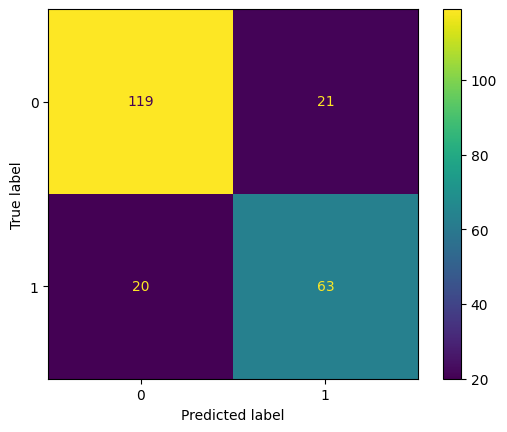

In [57]:
# 202435119 한여원
#logistic regerssion
from sklearn.linear_model import LogisticRegression

logit_reg = LogisticRegression(random_state=0, max_iter=1000)

logit_reg.fit(X1_train, y1_train)
y1_pred = logit_reg.predict(X1_test)

accuracy = metrics.accuracy_score(y1_test, y1_pred)
print(f"accuracy1 = {accuracy}")
print(f"{metrics.classification_report(y1_test, y1_pred)}")
disp = metrics.ConfusionMatrixDisplay.from_predictions(y1_test, y1_pred)
plt.show()

accuracy2 = 0.8071748878923767
              precision    recall  f1-score   support

           0       0.86      0.83      0.85       144
           1       0.71      0.76      0.74        79

    accuracy                           0.81       223
   macro avg       0.79      0.80      0.79       223
weighted avg       0.81      0.81      0.81       223



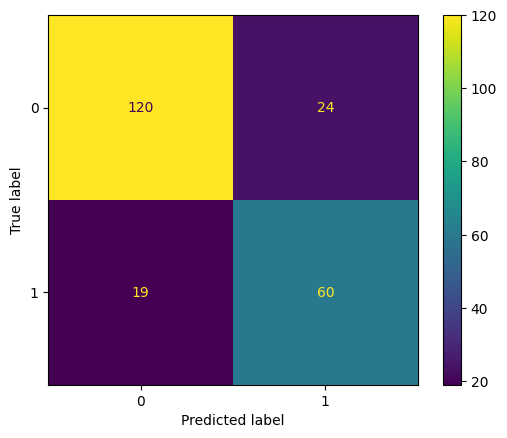

In [56]:
logit_reg = LogisticRegression(random_state=0, max_iter=1000)
logit_reg.fit(X2_train, y2_train)
y2_pred = logit_reg.predict(X2_test)

accuracy = metrics.accuracy_score(y2_test, y2_pred)
print(f"accuracy2 = {accuracy}")
print(f"{metrics.classification_report(y2_test, y2_pred)}")
disp = metrics.ConfusionMatrixDisplay.from_predictions(y2_test, y2_pred)
plt.show()

accuracy1 = 0.7533632286995515
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       140
           1       0.67      0.67      0.67        83

    accuracy                           0.75       223
   macro avg       0.74      0.74      0.74       223
weighted avg       0.75      0.75      0.75       223



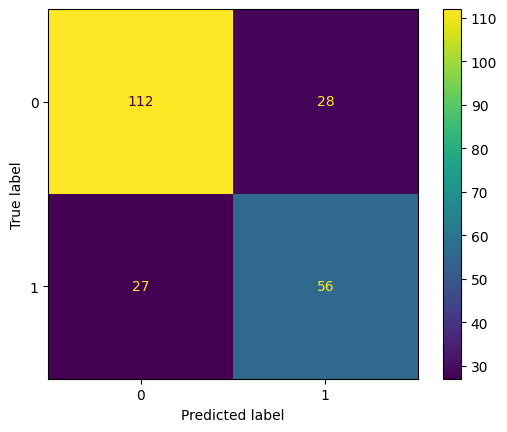

In [58]:
# 202435119 한여원
#decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(random_state=0)

dt_clf.fit(X1_train, y1_train)
y1_pred = dt_clf.predict(X1_test)

accuracy = metrics.accuracy_score(y1_test, y1_pred)
print(f"accuracy1 = {accuracy}")
print(f"{metrics.classification_report(y1_test, y1_pred)}")
disp = metrics.ConfusionMatrixDisplay.from_predictions(y1_test, y1_pred)
plt.show()

accuracy2 = 0.7937219730941704
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       144
           1       0.69      0.75      0.72        79

    accuracy                           0.79       223
   macro avg       0.77      0.78      0.78       223
weighted avg       0.80      0.79      0.80       223



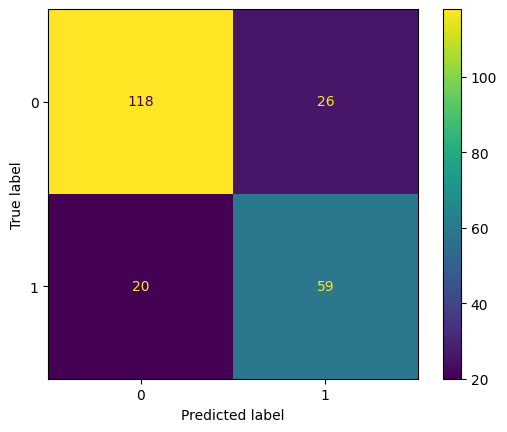

In [59]:
dt_clf = DecisionTreeClassifier(random_state=0)

dt_clf.fit(X2_train, y2_train)
y2_pred = dt_clf.predict(X2_test)

accuracy = metrics.accuracy_score(y2_test, y2_pred)
print(f"accuracy2 = {accuracy}")
print(f"{metrics.classification_report(y2_test, y2_pred)}")
disp = metrics.ConfusionMatrixDisplay.from_predictions(y2_test, y2_pred)
plt.show()

accuracy1 = 0.8251121076233184
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       140
           1       0.76      0.77      0.77        83

    accuracy                           0.83       223
   macro avg       0.81      0.81      0.81       223
weighted avg       0.83      0.83      0.83       223



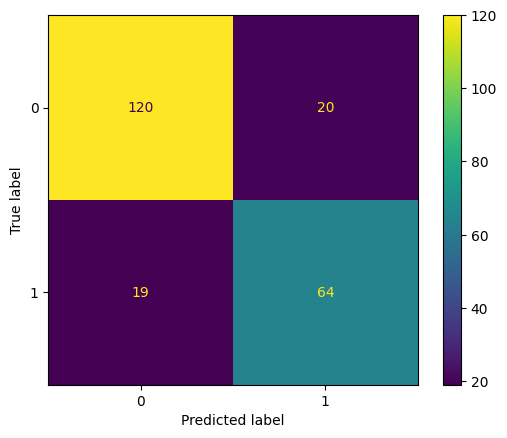

In [60]:
# 202435119 한여원
#random forest classifier

from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=0)

rf_clf.fit(X1_train, y1_train)
y1_pred = rf_clf.predict(X1_test)

accuracy = metrics.accuracy_score(y1_test, y1_pred)
print(f"accuracy1 = {accuracy}")
print(f"{metrics.classification_report(y1_test, y1_pred)}")
disp = metrics.ConfusionMatrixDisplay.from_predictions(y1_test, y1_pred)
plt.show()

accuracy2 = 0.820627802690583
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       144
           1       0.72      0.81      0.76        79

    accuracy                           0.82       223
   macro avg       0.80      0.82      0.81       223
weighted avg       0.83      0.82      0.82       223



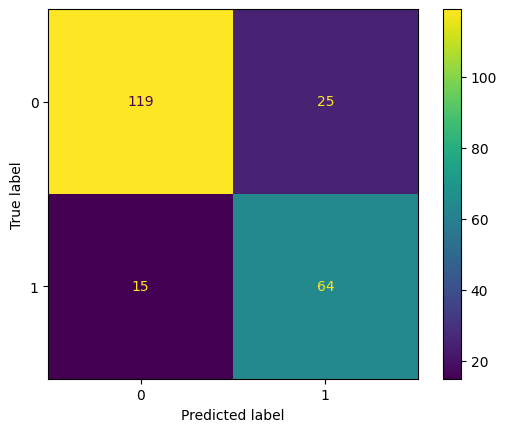

In [61]:
rf_clf = RandomForestClassifier(random_state=0)

rf_clf.fit(X2_train, y2_train)
y2_pred = rf_clf.predict(X2_test)

accuracy = metrics.accuracy_score(y2_test, y2_pred)
print(f"accuracy2 = {accuracy}")
print(f"{metrics.classification_report(y2_test, y2_pred)}")
disp = metrics.ConfusionMatrixDisplay.from_predictions(y2_test, y2_pred)
plt.show()

##### 결과적으로 봤을 때 유의미한 차이는 거의 일어나지 않았다. 
##### 이유는 아마 feature의 수가 적고, name, ticket, id 같은 값들이 원래부터 그다지 영향을 주지 않아 모델이 weight를 낮게 잡은 탓으로 보인다. 
##### 그나마 노이즈에 약한 DecisionTree에서 약간의 차이가 발생함